In [3]:
# =============================================================================
# Fase 2 - Redes Neuronales Feed-Forward
# Dataset: Adult Census Income (UCI Machine Learning Repository)
# =============================================================================
# Este notebook implementa y evalua tres arquitecturas de redes neuronales
# para clasificacion binaria sobre el dataset Adult preprocesado en la Fase 1:
#   Modelo A: Perceptron (clasificador lineal simple)
#   Modelo B: Red neuronal con una capa oculta (neuronas = variables de entrada)
#   Modelo C: Red neuronal con dos capas ocultas (2 neuronas cada una)
# Todos los modelos incluyen bias y los modelos B y C usan funcion sigmoide.
# Se evaluan con matriz de confusion, accuracy, precision, recall y F1-score.
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score,
                             ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Configuracion general
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_style("whitegrid")

print("Librerias cargadas correctamente.")
print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")
print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")

Librerias cargadas correctamente.
TensorFlow : 2.21.0
Keras      : 3.14.1
pandas     : 3.0.2
numpy      : 2.4.4


In [4]:
# =============================================================================
# Carga de datos preprocesados desde la Fase 1
# =============================================================================
# Se cargan los cuatro archivos CSV generados en la Fase 1 que contienen
# el dataset ya limpio, normalizado y particionado. Esto garantiza que
# los tres modelos se entrenen y evaluen exactamente sobre los mismos datos.
# =============================================================================

X_train = pd.read_csv('../datos/X_train.csv')
X_test  = pd.read_csv('../datos/X_test.csv')
y_train = pd.read_csv('../datos/y_train.csv').values.ravel()
y_test  = pd.read_csv('../datos/y_test.csv').values.ravel()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

# Numero de variables de entrada, necesario para definir el Modelo B
n_variables = X_train.shape[1]
print(f"\nNumero de variables de entrada: {n_variables}")
print(f"Distribucion de clases en y_train: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Distribucion de clases en y_test : {dict(zip(*np.unique(y_test, return_counts=True)))}")

X_train : (39073, 97)
X_test  : (9769, 97)
y_train : (39073,)
y_test  : (9769,)

Numero de variables de entrada: 97
Distribucion de clases en y_train: {np.int64(0): np.int64(29724), np.int64(1): np.int64(9349)}
Distribucion de clases en y_test : {np.int64(0): np.int64(7431), np.int64(1): np.int64(2338)}


In [5]:
# =============================================================================
# Funcion de evaluacion compartida
# =============================================================================
# Se define una funcion reutilizable que calcula y muestra todas las metricas
# requeridas por el enunciado para cada modelo: matriz de confusion, accuracy,
# precision, recall y F1-score. Al ser compartida garantiza que los tres
# modelos se evaluen con exactamente el mismo criterio.
# =============================================================================

def evaluar_modelo(nombre, y_real, y_pred, carpeta_graficas='graficas'):
    """
    Calcula y muestra las metricas de evaluacion de un modelo de clasificacion
    binaria y guarda la matriz de confusion como imagen.

    Parametros:
        nombre          : nombre del modelo para titulos y nombre del archivo
        y_real          : etiquetas reales del conjunto de prueba
        y_pred          : etiquetas predichas por el modelo
        carpeta_graficas: carpeta donde se guarda la imagen
    """
    acc  = accuracy_score(y_real, y_pred)
    prec = precision_score(y_real, y_pred, zero_division=0)
    rec  = recall_score(y_real, y_pred, zero_division=0)
    f1   = f1_score(y_real, y_pred, zero_division=0)
    cm   = confusion_matrix(y_real, y_pred)

    print(f"\n{'=' * 50}")
    print(f"METRICAS - {nombre}")
    print(f"{'=' * 50}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-score  : {f1:.4f}")

    # Matriz de confusion
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['<=50K', '>50K'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de confusion - {nombre}')
    plt.tight_layout()
    plt.savefig(f'graficas/confusion_{nombre.replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return {'modelo': nombre, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1}

# Crear carpeta de graficas si no existe
import os
os.makedirs('graficas', exist_ok=True)
print("Funcion de evaluacion definida correctamente.")

Funcion de evaluacion definida correctamente.


Model: "Modelo_A_Perceptron"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ salida (Dense)                       │ (None, 1)                   │              98 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 98 (392.00 B)

 Trainable params: 98 (392.00 B)

 Non-trainable params: 0 (0.00 B)


Entrenando Modelo A...
Entrenamiento completado.

METRICAS - Modelo A Perceptron
  Accuracy  : 0.8492  (84.92%)
  Precision : 0.7297
  Recall    : 0.5877
  F1-score  : 0.6510


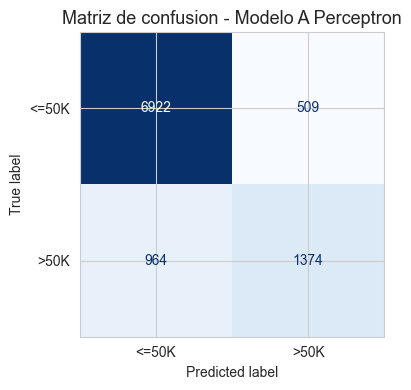

In [6]:
# =============================================================================
# Modelo A: Perceptron
# =============================================================================
# El perceptron es el clasificador lineal mas simple: una unica capa de
# entrada conectada directamente a una neurona de salida con funcion de
# activacion sigmoide. Incluye bias como lo exige el enunciado.
# Al ser lineal, solo puede separar clases que sean linealmente separables.
# Arquitectura: entrada (97) -> salida (1, sigmoide)
# =============================================================================

tf.random.set_seed(42)
np.random.seed(42)

modelo_A = keras.Sequential([
    # Capa de entrada con 97 variables
    layers.Input(shape=(n_variables,)),
    # Neurona de salida con bias incluido (use_bias=True es el valor por defecto)
    # Se usa sigmoide para obtener probabilidades entre 0 y 1
    layers.Dense(1, activation='sigmoid', use_bias=True, name='salida')
], name='Modelo_A_Perceptron')

modelo_A.summary()

# Compilacion del modelo
# binary_crossentropy es la funcion de perdida estandar para clasificacion binaria
# adam es el optimizador adaptativo mas usado en la practica
modelo_A.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento
print("\nEntrenando Modelo A...")
historia_A = modelo_A.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)
print("Entrenamiento completado.")

# Predicciones
# Se usa 0.5 como umbral de clasificacion: probabilidad >= 0.5 -> clase 1
y_pred_A = (modelo_A.predict(X_test, verbose=0) >= 0.5).astype(int).ravel()

# Evaluacion
resultados_A = evaluar_modelo('Modelo A Perceptron', y_test, y_pred_A)

Model: "Modelo_B_Una_Capa_Oculta"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ capa_oculta (Dense)                  │ (None, 97)                  │           9,506 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ salida (Dense)                       │ (None, 1)                   │              98 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,604 (37.52 KB)

 Trainable params: 9,604 (37.52 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando Modelo B...
Entrenamiento completado.

METRICAS - Modelo B Una Capa Oculta
  Accuracy  : 0.8513  (85.13%)
  Precision : 0.7365
  Recall    : 0.5894
  F1-score  : 0.6548


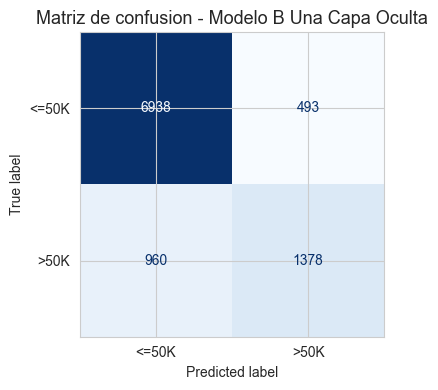

In [7]:
# =============================================================================
# Modelo B: Red Neuronal con una capa oculta
# =============================================================================
# Arquitectura con una capa oculta cuyo numero de neuronas es igual al numero
# de variables de entrada (97), tal como lo exige el enunciado.
# Tanto la capa oculta como la capa de salida usan funcion sigmoide y bias.
# Arquitectura: entrada (97) -> oculta (97, sigmoide) -> salida (1, sigmoide)
# =============================================================================

tf.random.set_seed(42)
np.random.seed(42)

modelo_B = keras.Sequential([
    layers.Input(shape=(n_variables,)),
    # Capa oculta con n_variables neuronas, sigmoide y bias
    layers.Dense(n_variables, activation='sigmoid',
                 use_bias=True, name='capa_oculta'),
    # Capa de salida con sigmoide y bias
    layers.Dense(1, activation='sigmoid',
                 use_bias=True, name='salida')
], name='Modelo_B_Una_Capa_Oculta')

modelo_B.summary()

modelo_B.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nEntrenando Modelo B...")
historia_B = modelo_B.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)
print("Entrenamiento completado.")

y_pred_B = (modelo_B.predict(X_test, verbose=0) >= 0.5).astype(int).ravel()

resultados_B = evaluar_modelo('Modelo B Una Capa Oculta', y_test, y_pred_B)

Model: "Modelo_C_Dos_Capas_Ocultas"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ capa_oculta_1 (Dense)                │ (None, 2)                   │             196 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ capa_oculta_2 (Dense)                │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ salida (Dense)                       │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 205 (820.00 B)

 Trainable params: 205 (820.00 B)

 Non-trainable params: 0 (0.00 B)


Entrenando Modelo C...
Entrenamiento completado.

METRICAS - Modelo C Dos Capas Ocultas
  Accuracy  : 0.8502  (85.02%)
  Precision : 0.7301
  Recall    : 0.5937
  F1-score  : 0.6549


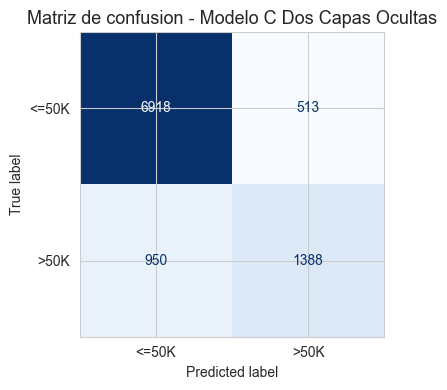

In [8]:
# =============================================================================
# Modelo C: Red Neuronal con dos capas ocultas
# =============================================================================
# Arquitectura con dos capas ocultas de exactamente 2 neuronas cada una,
# tal como lo exige el enunciado. Todas las capas usan sigmoide y bias.
# Esta arquitectura es intencionalmente restrictiva: con solo 2 neuronas
# por capa el modelo tiene muy poca capacidad de representacion, lo que
# se reflejara en las metricas finales.
# Arquitectura: entrada (97) -> oculta1 (2, sigmoide) -> oculta2 (2, sigmoide)
#               -> salida (1, sigmoide)
# =============================================================================

tf.random.set_seed(42)
np.random.seed(42)

modelo_C = keras.Sequential([
    layers.Input(shape=(n_variables,)),
    # Primera capa oculta con exactamente 2 neuronas
    layers.Dense(2, activation='sigmoid',
                 use_bias=True, name='capa_oculta_1'),
    # Segunda capa oculta con exactamente 2 neuronas
    layers.Dense(2, activation='sigmoid',
                 use_bias=True, name='capa_oculta_2'),
    # Capa de salida
    layers.Dense(1, activation='sigmoid',
                 use_bias=True, name='salida')
], name='Modelo_C_Dos_Capas_Ocultas')

modelo_C.summary()

modelo_C.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nEntrenando Modelo C...")
historia_C = modelo_C.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)
print("Entrenamiento completado.")

y_pred_C = (modelo_C.predict(X_test, verbose=0) >= 0.5).astype(int).ravel()

resultados_C = evaluar_modelo('Modelo C Dos Capas Ocultas', y_test, y_pred_C)

TABLA COMPARATIVA DE LOS TRES MODELOS


,accuracy,precision,recall,f1
modelo,,,,
Modelo A Perceptron,0.8492,0.7297,0.5877,0.6510
Modelo B Una Capa Oculta,0.8513,0.7365,0.5894,0.6548
Modelo C Dos Capas Ocultas,0.8502,0.7301,0.5937,0.6549


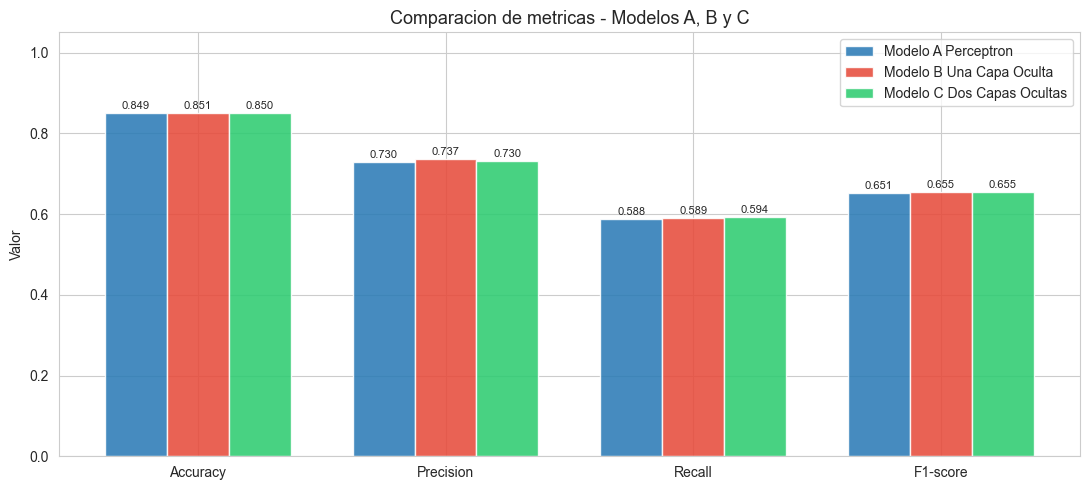

Grafica guardada.


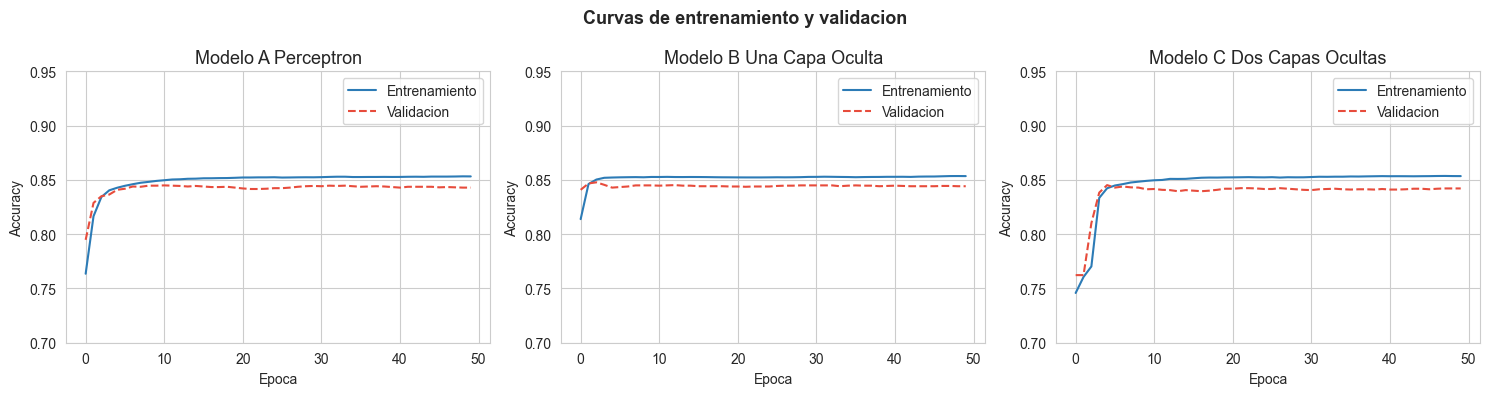

Grafica guardada.


In [9]:
# =============================================================================
# Analisis comparativo de los tres modelos
# =============================================================================
# Se consolidan las metricas de los tres modelos en una tabla comparativa
# y se visualizan en una grafica de barras agrupadas para facilitar
# la comparacion directa entre arquitecturas.
# =============================================================================

# Tabla comparativa
df_resultados = pd.DataFrame([resultados_A, resultados_B, resultados_C])
df_resultados = df_resultados.set_index('modelo')
df_resultados = df_resultados.round(4)

print("=" * 60)
print("TABLA COMPARATIVA DE LOS TRES MODELOS")
print("=" * 60)
display(df_resultados)

# Grafica comparativa
fig, ax = plt.subplots(figsize=(11, 5))
metricas = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metricas))
ancho = 0.25
colores = ['#2c7bb6', '#e74c3c', '#2ecc71']

for i, (idx, row) in enumerate(df_resultados.iterrows()):
    valores = [row[m] for m in metricas]
    barras = ax.bar(x + i * ancho, valores, ancho,
                    label=idx, color=colores[i], alpha=0.88)
    for barra in barras:
        ax.text(barra.get_x() + barra.get_width() / 2,
                barra.get_height() + 0.005,
                f'{barra.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + ancho)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-score'])
ax.set_ylabel('Valor')
ax.set_ylim(0, 1.05)
ax.set_title('Comparacion de metricas - Modelos A, B y C')
ax.legend()
plt.tight_layout()
plt.savefig('graficas/comparativo_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada.")

# Curvas de entrenamiento
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
historias = [historia_A, historia_B, historia_C]
nombres = ['Modelo A Perceptron', 'Modelo B Una Capa Oculta',
           'Modelo C Dos Capas Ocultas']

for i, (hist, nombre) in enumerate(zip(historias, nombres)):
    axes[i].plot(hist.history['accuracy'], label='Entrenamiento', color='#2c7bb6')
    axes[i].plot(hist.history['val_accuracy'], label='Validacion',
                 color='#e74c3c', linestyle='--')
    axes[i].set_title(nombre)
    axes[i].set_xlabel('Epoca')
    axes[i].set_ylabel('Accuracy')
    axes[i].legend()
    axes[i].set_ylim(0.7, 0.95)

plt.suptitle('Curvas de entrenamiento y validacion', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.savefig('graficas/curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada.")